In [24]:
text = """
Input | 86% | 98% | 98% | 100% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% |
Query | 15% | 68% | 60% | 44% | 62% | 44% | 43% | 32% | 44% | 34% | 45% | 54% | 49% | 61% | 50% | 50% |
Key | 4% | 69% | 50% | 22% | 55% | 24% | 34% | 12% | 42% | 18% | 22% | 30% | 46% | 43% | 36% | 52% |
Value | 13% | 52% | 22% | 36% | 51% | 25% | 16% | 13% | 12% | 25% | 70% | 71% | 63% | 59% | 67% | 59% |
Q+K+V | 20% | 98% | 96% | 90% | 89% | 85% | 62% | 66% | 65% | 79% | 100% | 99% | 99% | 99% | 99% | 99% |
Attn output | 1% | 42% | 2% | 4% | 12% | 0% | 1% | 0% | 0% | 1% | 77% | 0% | 8% | 1% | 12% | 96% |
MLP output | 58% | 51% | 42% | 51% | 40% | 34% | 29% | 40% | 53% | 51% | 56% | 47% | 38% | 38% | 29% | 17% |
+residuals | 98% | 98% | 100% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 99% | 44% | 
"""

/tmp/ipykernel_3538967/3160826425.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = df.applymap(lambda v: "" if pd.isna(v) else v)


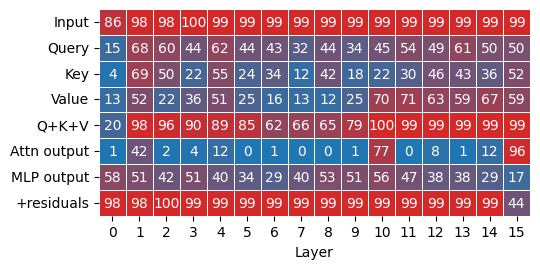

In [37]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# ---------- Parse to DataFrame ----------
rows = {}
for line in text.strip().splitlines():
    parts = [p.strip() for p in line.split("|") if p.strip()]
    name, values = parts[0], parts[1:]
    values = [np.nan if v == "--" else int(re.sub(r"%", "", v)) for v in values]
    rows[name] = values

n_cols = max(len(v) for v in rows.values())
data = {name: (vals + [np.nan] * (n_cols - len(vals)))[:n_cols] for name, vals in rows.items()}
df = pd.DataFrame(data, index=[list(range(n_cols))]).T

# ---------- Heatmap ----------
values_01 = df / 100.0
annot_labels = df.applymap(lambda v: "" if pd.isna(v) else v)

# custom blue-to-red colormap
cmap = mcolors.LinearSegmentedColormap.from_list("blue_red", ["#1f77b4", "#d62728"])

plt.figure(figsize=(5.5, 2.8))
ax = sns.heatmap(
    values_01,
    annot=df,
    fmt="",
    cmap=cmap,
    vmin=0, vmax=1,        # scale to 0–1 since these are accuracies
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Accuracy"}
)

ax.set_xlabel("Layer")
# ax.set_ylabel("Component")
# ax.set_title("Layer-wise Accuracies")
ax.collections[0].colorbar.remove()

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
ax.figure.savefig("in_layer_accs.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()